In [1]:
# === project setup ===
from pathlib import Path

import sys

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    for parent in PROJECT_ROOT.parents:
        if (parent / "src").exists():
            PROJECT_ROOT = parent
            break

print("PROJECT_ROOT =", PROJECT_ROOT)

if not (PROJECT_ROOT / "src").exists():
    raise RuntimeError("src directory not found - wrong PROJECT_ROOT")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROJECT_ROOT = C:\Users\hodor\Documents\lab-Shishkin\projects\BCI_classifier


In [2]:
# === imports ===
import json
from h5py import File

import numpy as np
import pandas as pd

try:
    from IPython.display import display
except ImportError:
    display = print

from src.analysis.CSP import compute_csp
from src.analysis.preprocessing import bandpass_filter, read_good_epoch_mask
from src.utils.montage_processing import get_channel_names

In [9]:
# === data and CSP config ===
project = "pr_Agency_EBCI"
stage = "test"
session = "05_08 Artem"
record = "EPOCHS_02_calib.hdf"

record_path = PROJECT_ROOT / "data" / project / "trans" / stage / session / record
montage_path = PROJECT_ROOT / "resources" / "mks64_standard.ced"

config = {
    "Fs": 1000,
    "baseline_ms": 500,
    "start_shift_ms": 1000,
    "end_shift_ms": 0,
}

config_csp = {
    "band": [8.0, 12.0],
    "robust": True,
    "concat": True,
    "regularization": False,
    "alpha": 0.1,
}

bad_channels = ["FT9", "TP9", "T7", "AF7", "AF8", "FT10", "TP10", "T8"]
all_channel_names = list(get_channel_names(str(montage_path)))
channel_names = [ch for ch in all_channel_names if ch not in bad_channels]

print("record_path =", record_path)
print("band =", config_csp["band"], "Hz")

record_path = C:\Users\hodor\Documents\lab-Shishkin\projects\BCI_classifier\data\pr_Agency_EBCI\trans\test\05_08 Artem\EPOCHS_02_calib.hdf
band = [8.0, 12.0] Hz


In [10]:
csp_record = f"MATRIX_{str(config_csp["band"])}_robust_concat+reg0.01_{record[record.find("_")+1:]}"
matrix_path = PROJECT_ROOT / "data" / project / "features" / "csp" / stage / session / csp_record

In [14]:
with File(matrix_path, "r") as h5f:
    W = h5f["projInverse"][:]
    A = h5f["projInverse"][:]
    eigvals = h5f["evals"][:]
components = [f"CSP_{idx + 1:02d}" for idx in range(W.shape[1])]
W_df = pd.DataFrame(W, index=channel_names, columns=components)
A_df = pd.DataFrame(A, index=channel_names, columns=components)
eigvals_df = pd.DataFrame({"eigval": eigvals}, index=components)

In [25]:
with File(record_path, "r") as h5f:
    epochs = h5f["epochs"][:]
    labels = h5f["labels"][:]

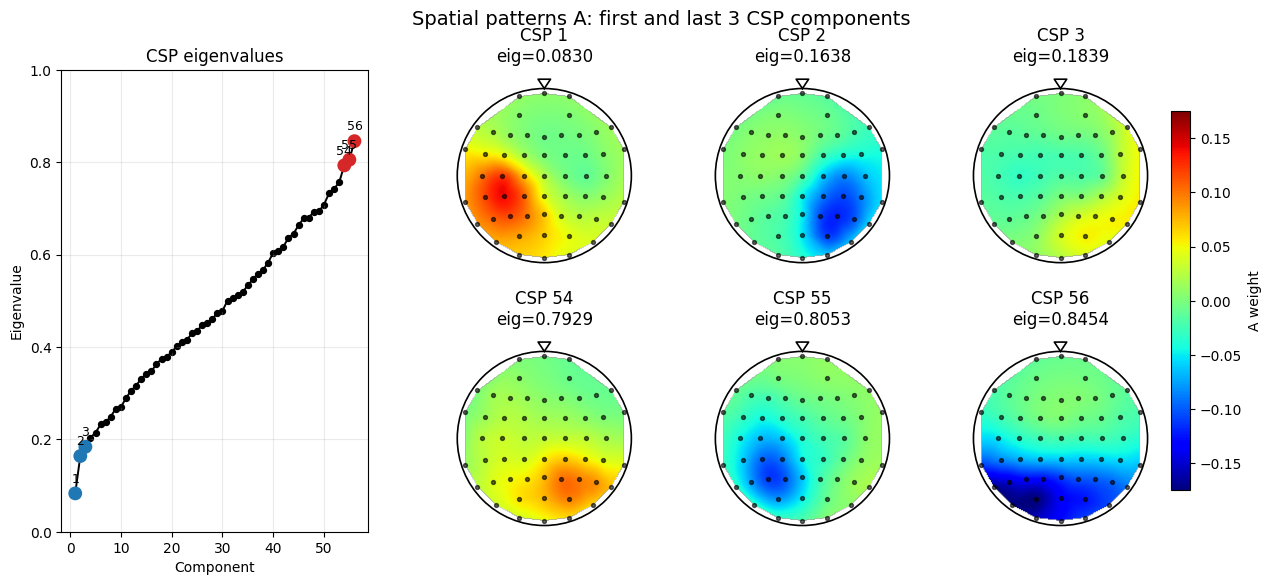

In [17]:
# === plot first and last 3 CSP spatial patterns ===
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from scipy.interpolate import griddata

from src.utils.montage_processing import get_topo_positions

pattern_indices = list(range(3)) + list(range(A.shape[1] - 3, A.shape[1]))
channel_indices = [all_channel_names.index(ch) for ch in channel_names]
xy = get_topo_positions(str(montage_path))[channel_indices]

vmax = np.nanmax(np.abs(A[:, pattern_indices]))
grid_x, grid_y = np.mgrid[-0.6:0.6:180j, -0.6:0.6:180j]
head_radius = 0.56
head_mask = grid_x**2 + grid_y**2 > head_radius**2

def plot_spatial_pattern(ax, values, title):
    grid = griddata(xy, values, (grid_x, grid_y), method="cubic")
    grid = np.ma.array(grid, mask=head_mask | np.isnan(grid))
    im = ax.imshow(
        grid.T,
        origin="lower",
        extent=(-0.6, 0.6, -0.6, 0.6),
        cmap="jet",
        vmin=-vmax,
        vmax=vmax,
        interpolation="bilinear",
    )
    ax.scatter(xy[:, 0], xy[:, 1], s=8, c="black", alpha=0.6)
    ax.add_patch(Circle((0, 0), head_radius, edgecolor="black", facecolor="none", lw=1.2))
    ax.plot([0, -0.04, 0.04, 0], [head_radius, head_radius + 0.06, head_radius + 0.06, head_radius], color="black", lw=1.2)
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.axis("off")
    return im

fig = plt.figure(figsize=(16, 6))
gs = fig.add_gridspec(2, 4, width_ratios=[1.25, 1, 1, 1], wspace=0.25, hspace=0.32)

ax_eig = fig.add_subplot(gs[:, 0])
component_numbers = np.arange(1, len(eigvals) + 1)
selected_numbers = np.array(pattern_indices) + 1
selected_colors = ["tab:blue"] * 3 + ["tab:red"] * 3

ax_eig.plot(component_numbers, eigvals, color="black", lw=1.4)
ax_eig.scatter(component_numbers, eigvals, s=18, color="black")
ax_eig.scatter(selected_numbers, eigvals[pattern_indices], s=80, color=selected_colors, zorder=3)
for comp_idx in pattern_indices:
    ax_eig.annotate(
        f"{comp_idx + 1}",
        (comp_idx + 1, eigvals[comp_idx]),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=9,
    )
ax_eig.set_title("CSP eigenvalues")
ax_eig.set_xlabel("Component")
ax_eig.set_ylabel("Eigenvalue")
ax_eig.set_ylim(0, 1)
ax_eig.grid(alpha=0.25)

for plot_number, comp_idx in enumerate(pattern_indices):
    row = plot_number // 3
    col = plot_number % 3 + 1
    ax = fig.add_subplot(gs[row, col])
    title = f"CSP {comp_idx + 1}\neig={eigvals[comp_idx]:.4f}"
    im = plot_spatial_pattern(ax, A[:, comp_idx], title)

cbar = fig.colorbar(im, ax=fig.axes[1:], shrink=0.82, pad=0.02)
cbar.set_label("A weight")
fig.suptitle("Spatial patterns A: first and last 3 CSP components", fontsize=14)
plt.show()

# собственные значения

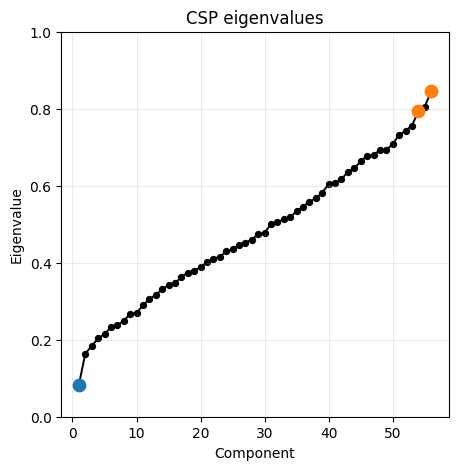

In [100]:
ediff = np.diff(eigvals)
ediff_lim = 2 * np.median(ediff)

max_edge = 10
left = np.where(ediff[:max_edge+1] > ediff_lim)[0]
right = len(eigvals)-max_edge+np.where(ediff[-max_edge:] > ediff_lim)[0]

fig, ax_eig = plt.subplots(1, 1, figsize=(5, 5))
ax_eig.plot(component_numbers, eigvals, color="black", lw=1.4)
ax_eig.scatter(component_numbers, eigvals, s=18, color="black")
ax_eig.scatter(left+1, eigvals[left], s=80, zorder=3)
ax_eig.scatter(right+1, eigvals[right], s=80, zorder=3)

ax_eig.set_title("CSP eigenvalues")
ax_eig.set_xlabel("Component")
ax_eig.set_ylabel("Eigenvalue")
ax_eig.set_ylim(0, 1)
ax_eig.grid(alpha=0.25)


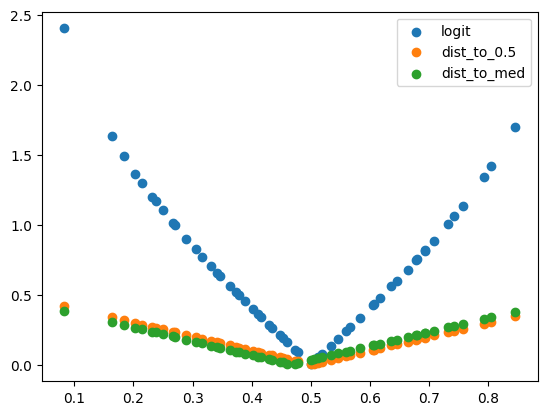

In [ ]:
def calculate_eigenscore(evals):
    eig_score = np.abs(np.log(evals / (1 - evals) + 1e-10))
    return np.round(eig_score, 3)

eigscore_logit = calculate_eigenscore(eigvals)            # логит-преобразование
eigscore_0_5 =  np.abs(eigvals - 0.5)
eigscore_med =  np.abs(eigvals - np.median(eigvals))
plt.scatter(eigvals, eigscore_logit, label='logit')
plt.scatter(eigvals, eigscore_0_5, label="dist_to_0.5")
plt.scatter(eigvals, eigscore_med, label="dist_to_med")

plt.legend()

# дипольный анализ

Для каждой CSP-компоненты:

1. Взять CSP pattern, а не CSP filter.

2. Сделать dipole fit:
   - получить GOF
   - получить координаты
   - получить ориентацию

3. Сделать проверку локализации:
   - расстояние до C3/C4/Cz
   - расстояние до заданной сенсомоторной ROI
   - находится ли источник внутри реалистичной области головы

4. Сделать leadfield scan:
   - получить карту соответствия pattern ↔ leadfield
   - найти максимум
   - оценить долю score в sensorimotor ROI
   - оценить компактность

5. Рассчитать итоговый physiological_score.

6. Отбирать компоненты не по одному порогу, а по рангу.

In [100]:
# phys_score = (
#     0.35 * discriminative_score +
#     0.25 * sensorimotor_score +
#     0.20 * dipolarity_score +
#     0.20 * compactness_score
# )
# discriminative_score — насколько CSP-компонента разделяет классы
# sensorimotor_score — насколько источник близко к M1/S1/SMA
# dipolarity_score — GOF / 100
# compactness_score — насколько leadfield scan имеет один выраженный максимум

In [26]:
# === prepare MNE Epochs and fit CSP dipoles ===
from mne.transforms import Transform
import mne

def make_mne_epochs_from_numpy(epochs_array, labels, channel_names, montage_path, fs, baseline_ms):
    ced = pd.read_csv(montage_path, sep="\t").set_index("labels")
    missing_channels = [ch for ch in channel_names if ch not in ced.index]
    if missing_channels:
        raise ValueError(f"Channels are missing in montage: {missing_channels}")

    # CED coordinates are in EEGLAB/BESA-like axes; convert to MNE head: x=right, y=anterior, z=up.
    ch_pos = {
        ch: np.array([-ced.loc[ch, "Y"], ced.loc[ch, "X"], ced.loc[ch, "Z"]], dtype=float)
        for ch in channel_names
    }
    montage = mne.channels.make_dig_montage(ch_pos=ch_pos, coord_frame="head")

    info = mne.create_info(channel_names, sfreq=fs, ch_types="eeg")
    info.set_montage(montage, on_missing="raise")
    info["dev_head_t"] = Transform("meg", "head", np.eye(4))

    epochs_mne = mne.EpochsArray(
        np.transpose(epochs_array, (0, 2, 1)),
        info,
        tmin=-baseline_ms / 1000,
        events=np.c_[np.arange(len(labels)), np.zeros(len(labels), dtype=int), labels.astype(int)],
        event_id={str(label): int(label) for label in np.unique(labels)},
        verbose=False,
    )
    epochs_mne.set_eeg_reference("average", projection=True, verbose=False)
    epochs_mne.apply_proj(verbose=False)
    epochs_mne.apply_baseline((None, 0), verbose=False)
    return epochs_mne


mne_epochs = make_mne_epochs_from_numpy(
    epochs_array=epochs,
    labels=labels,
    channel_names=channel_names,
    montage_path=montage_path,
    fs=config["Fs"],
    baseline_ms=config["baseline_ms"],
)

sphere = mne.make_sphere_model(
    r0="auto",
    head_radius="auto",
    info=mne_epochs.info,
    verbose=False
)

In [27]:
cov = mne.compute_covariance(
        mne_epochs,
        tmin=None,
        tmax=0,
        method="empirical",
        rank=None,
        verbose=False,
    )

In [ ]:
dipoles = []
n =3 
patterns = A[:, :n].T
cov = mne.compute_covariance(
        mne_epochs,
        tmin=None,
        tmax=0,
        method="empirical",
        rank=None,
        verbose=False,
    )
tmin=0.0
def calculate_dipole(data):
    evoked_info = mne_epochs.info.copy()
    if evoked_info["dev_head_t"] is None:
        evoked_info["dev_head_t"] = Transform("meg", "head", np.eye(4))

    evoked = mne.EvokedArray(
        data,
        info=evoked_info,
        tmin=tmin,
        nave=len(mne_epochs),
    )

    with mne.use_log_level("WARNING"):
        dip, residual = mne.fit_dipole(
            evoked,
            cov=cov,
            bem=sphere,
            trans=None,
            n_jobs=1,
            verbose=False,
        )
    return {
            "component": k,
            "pattern": pattern,
            "dipole": dip,
            "residual": residual,
            "gof": dip.gof[0],
            "pos_m": dip.pos[0],
            "ori": dip.ori[0],
            "amplitude": dip.amplitude[0],
        }

for k, pattern in enumerate(patterns):
    data = pattern[:, np.newaxis]
    dipoles.append(calculate_dipole(data))

dipoles_df = pd.DataFrame([
    {
        "component": item["component"] + 1,
        "gof": item["gof"],
        "x_mm": item["pos_m"][0] * 1000,
        "y_mm": item["pos_m"][1] * 1000,
        "z_mm": item["pos_m"][2] * 1000,
        "ori_x": item["ori"][0],
        "ori_y": item["ori"][1],
        "ori_z": item["ori"][2],
        "amplitude": item["amplitude"],
    }
    for item in dipoles
])

display(dipoles_df)

,component,gof,x_mm,y_mm,z_mm,ori_x,ori_y,ori_z,amplitude
0,1,68.385373,-47.018162,-1.717513,53.220721,-0.713458,-0.687996,0.132815,0.000359
1,2,47.199560,16.218138,-68.114652,34.011393,-0.857104,0.510265,-0.070728,0.000270
2,3,39.733351,70.304018,25.541063,14.672616,0.647784,-0.193568,-0.736822,0.000170


In [1]:
ROIS = {
    "left_M1_hand":  {"center": [-36, -24, 56], "radius": 25, "weight": 1.0},
    "left_S1_hand":  {"center": [-42, -30, 52], "radius": 25, "weight": 0.8},
    "SMA":           {"center": [0, -6, 58],    "radius": 25, "weight": 0.7},
    "left_PMd":      {"center": [-28, -8, 56],  "radius": 25, "weight": 0.6},
}

In [101]:
dipoles = []
n =3 
patterns = A[:, -n:].T
cov = mne.compute_covariance(
        mne_epochs,
        tmin=None,
        tmax=0,
        method="empirical",
        rank=None,
        verbose=False,
    )
tmin=0.0
def calculate_dipole(data):
    evoked_info = mne_epochs.info.copy()
    if evoked_info["dev_head_t"] is None:
        evoked_info["dev_head_t"] = Transform("meg", "head", np.eye(4))

    evoked = mne.EvokedArray(
        data,
        info=evoked_info,
        tmin=tmin,
        nave=len(mne_epochs),
    )

    with mne.use_log_level("WARNING"):
        dip, residual = mne.fit_dipole(
            evoked,
            cov=cov,
            bem=sphere,
            trans=None,
            n_jobs=1,
            verbose=False,
        )
    return {
            "component": k,
            "pattern": pattern,
            "dipole": dip,
            "residual": residual,
            "gof": dip.gof[0],
            "pos_m": dip.pos[0],
            "ori": dip.ori[0],
            "amplitude": dip.amplitude[0],
        }

for k, pattern in enumerate(patterns):
    data = pattern[:, np.newaxis]
    dipoles.append(calculate_dipole(data))

dipoles_df = pd.DataFrame([
    {
        "component": item["component"] + 1,
        "gof": item["gof"],
        "x_mm": item["pos_m"][0] * 1000,
        "y_mm": item["pos_m"][1] * 1000,
        "z_mm": item["pos_m"][2] * 1000,
        "ori_x": item["ori"][0],
        "ori_y": item["ori"][1],
        "ori_z": item["ori"][2],
        "amplitude": item["amplitude"],
    }
    for item in dipoles
])

display(dipoles_df)

,component,gof,x_mm,y_mm,z_mm,ori_x,ori_y,ori_z,amplitude
0,1,44.921042,21.866409,-39.917335,46.310990,0.200835,-0.900438,0.385845,0.000277
1,2,55.301545,-34.178508,-49.272958,27.536497,0.429225,0.456946,-0.779080,0.000334
2,3,43.694152,-30.705430,-42.136859,47.681622,-0.501440,0.847263,0.175224,0.000262


In [39]:
def distance_mm(a, b):
    """Euclidean distance between two 3D points in mm."""
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    return np.linalg.norm(a - b)


def get_electrode_pos_mm(info, ch_name):
    """Get electrode position from MNE info in mm."""
    montage = info.get_montage()
    if montage is None:
        raise ValueError("No montage found in info.")

    ch_pos = montage.get_positions()["ch_pos"]

    if ch_name not in ch_pos:
        raise ValueError(f"Channel {ch_name} not found in montage.")

    return np.asarray(ch_pos[ch_name]) * 1000  # m → mm


def make_csp_physiology_table(
    csp,
    dipoles,
    info,
    eigenvalues=None,
    sensorimotor_channels=("C3", "C4", "Cz"),
    min_gof=60,
    good_gof=85,
    max_sensorimotor_dist_mm=50,
):
    """
    Create a table for physiological evaluation of CSP components.

    Parameters
    ----------
    csp : fitted mne.decoding.CSP
        Fitted CSP object.
    dipoles : list of dict
        Output list from previous fit_csp_dipoles function.
        Each element should contain:
        'component', 'gof', 'pos_m', 'ori', 'amplitude'
    info : mne.Info
        MNE info with montage.
    eigenvalues : array | None
        CSP eigenvalues or discriminative scores, if available.
    sensorimotor_channels : tuple
        Channels used as rough sensorimotor landmarks.
    min_gof : float
        Minimum acceptable GOF.
    good_gof : float
        GOF considered strongly dipolar.
    max_sensorimotor_dist_mm : float
        Maximum distance to sensorimotor landmark.

    Returns
    -------
    df : pandas.DataFrame
    """

    landmarks = {
        ch: get_electrode_pos_mm(info, ch)
        for ch in sensorimotor_channels
    }

    rows = []

    for d in dipoles:
        comp = d["component"]

        pos_mm = np.asarray(d["pos_m"]) * 1000
        ori = np.asarray(d["ori"])
        gof = float(d["gof"])
        rv = 100 - gof

        distances = {
            f"dist_{ch}_mm": distance_mm(pos_mm, coord)
            for ch, coord in landmarks.items()
        }

        nearest_ch = min(
            sensorimotor_channels,
            key=lambda ch: distances[f"dist_{ch}_mm"]
        )

        nearest_dist = distances[f"dist_{nearest_ch}_mm"]

        dipolarity_score = np.clip(gof / 100, 0, 1)

        sensorimotor_score = np.clip(
            1 - nearest_dist / max_sensorimotor_dist_mm,
            0,
            1
        )

        if eigenvalues is not None:
            eig = float(eigenvalues[comp])
            # чем дальше от 0.5, тем сильнее CSP-компонента
            discriminative_score = abs(eig - 0.5) * 2
            discriminative_score = np.clip(discriminative_score, 0, 1)
        else:
            eig = np.nan
            discriminative_score = np.nan

        if np.isnan(discriminative_score):
            phys_score = (
                0.45 * sensorimotor_score +
                0.35 * dipolarity_score
            )
        else:
            phys_score = (
                0.35 * discriminative_score +
                0.35 * sensorimotor_score +
                0.30 * dipolarity_score
            )

        if gof >= good_gof:
            dipolarity_label = "strongly_dipolar"
        elif gof >= min_gof:
            dipolarity_label = "moderately_dipolar"
        else:
            dipolarity_label = "poorly_dipolar"

        selected = (
            gof >= min_gof
            and nearest_dist <= max_sensorimotor_dist_mm
        )

        row = {
            "component": comp,
            "eigenvalue": eig,
            "gof": gof,
            "rv": rv,
            "x_mm": pos_mm[0],
            "y_mm": pos_mm[1],
            "z_mm": pos_mm[2],
            "ori_x": ori[0],
            "ori_y": ori[1],
            "ori_z": ori[2],
            "amplitude": d.get("amplitude", np.nan),
            "nearest_sensorimotor_ch": nearest_ch,
            "nearest_sensorimotor_dist_mm": nearest_dist,
            "dipolarity_score": dipolarity_score,
            "sensorimotor_score": sensorimotor_score,
            "discriminative_score": discriminative_score,
            "phys_score": phys_score,
            "dipolarity_label": dipolarity_label,
            "selected": selected,
        }

        row.update(distances)
        rows.append(row)

    df = pd.DataFrame(rows)

    return df.sort_values("phys_score", ascending=False).reset_index(drop=True)

In [ ]:
df_phys = make_csp_physiology_table(
    csp= ,
    dipoles=dipoles,
    info=mne_epochs.info,
    eigenvalues=eigvals,
    sensorimotor_channels=("C3", "C4", "Cz"),
    min_gof=60,
    good_gof=85,
    max_sensorimotor_dist_mm=50,
)

df_phys

NameError: name 'mne_csp' is not defined

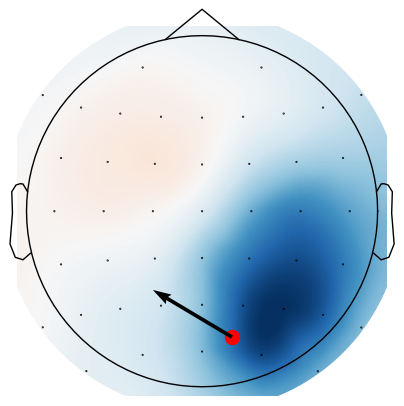

In [28]:
fig, ax = plt.subplots()

k = 1
mne.viz.plot_topomap(
    A[:, k],
    mne_epochs.info,
    contours=0,
    axes=ax,
    show=False
)

from mne.channels.layout import _find_topomap_coords

picks = mne.pick_types(mne_epochs.info, eeg=True)
coords2d = _find_topomap_coords(
    mne_epochs.info,
    picks=picks
)

pos = dipoles_df[["x_mm", "y_mm", "z_mm"]].iloc[k].values
ori = dipoles_df[["ori_x", "ori_y", "ori_z"]].iloc[k].values

x, y, z = pos[0], pos[1], pos[2]
u, v = ori[0], ori[1]

dip2d = pos[:2] / 1000

x, y = dip2d[0], dip2d[1]
ax.scatter(x, y, s=100, c="red", zorder=10)

ax.quiver(
    x, y,
    u, v,
    # angles="xy",
    scale_units="xy",
    scale=20,
    color="black",
    width=0.01,
    zorder=11
)

ax.set_aspect("equal")
plt.xlim(-0.1, 0.1)
plt.ylim(-0.1, 0.1)
plt.show()

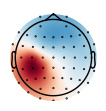

In [ ]:
k = 0
mne.viz.plot_topomap(
    mne_csp.patterns_[k],
    mne_epochs.info,
    contours=0,
)
pos = dipoles_df[["x_mm", "y_mm", "z_mm"]].iloc[0].values
ori = dipoles_df[["ori_x", "ori_y", "ori_z"]].iloc[0].values


In [68]:
pos2d = mne.channels.layout._find_topomap_coords(
    mne_epochs.info,
    picks=mne.pick_types(mne_epochs.info, eeg=True)
)

print(pos2d.min(axis=0))
print(pos2d.max(axis=0))

[-0.10132227 -0.10707262]
[0.10132227 0.10707262]


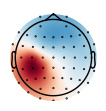

In [82]:
k = 0
mne.viz.plot_topomap(
    mne_csp.patterns_[k],
    mne_epochs.info,
    contours=0,
    # axes=ax,
    show=False
)
plt.show()

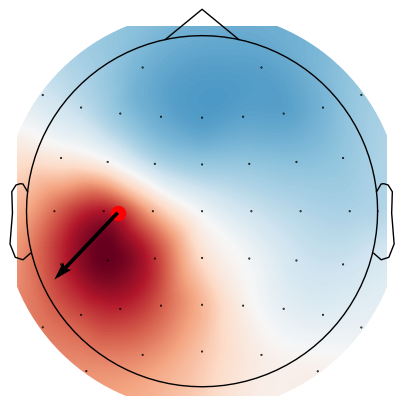

In [95]:
fig, ax = plt.subplots()

k = 0
mne.viz.plot_topomap(
    mne_csp.patterns_[k],
    mne_epochs.info,
    contours=0,
    axes=ax,
    show=False
)

from mne.channels.layout import _find_topomap_coords

picks = mne.pick_types(mne_epochs.info, eeg=True)
coords2d = _find_topomap_coords(
    mne_epochs.info,
    picks=picks
)

pos = dipoles_df[["x_mm", "y_mm", "z_mm"]].iloc[k].values
ori = dipoles_df[["ori_x", "ori_y", "ori_z"]].iloc[k].values

x, y, z = pos[0], pos[1], pos[2]
u, v = ori[0], ori[1]

dip2d = pos[:2] / 1000

x, y = dip2d[0], dip2d[1]
ax.scatter(x, y, s=100, c="red", zorder=10)

ax.quiver(
    x, y,
    u, v,
    # angles="xy",
    scale_units="xy",
    scale=20,
    color="black",
    width=0.01,
    zorder=11
)

ax.set_aspect("equal")
plt.xlim(-0.1, 0.1)
plt.ylim(-0.1, 0.1)
plt.show()

In [88]:
dip2d

array([-0.45661497, -0.0080438 ])

In [96]:
def leadfield_scan_csp_pattern(pattern, info, fwd, picks=None):
    """
    pattern : array, shape (n_channels,)
        CSP pattern.
    info : mne.Info
    fwd : mne.Forward
        Forward solution with free orientation.
    """

    if picks is None:
        picks = mne.pick_types(info, eeg=True, meg=False, exclude="bads")

    # оставляем те же каналы, что в forward
    fwd_ch_names = fwd["info"]["ch_names"]
    info_ch_names = np.array(info["ch_names"])

    pick_names = [info_ch_names[p] for p in picks]
    common = [ch for ch in pick_names if ch in fwd_ch_names]

    info_idx = [info["ch_names"].index(ch) for ch in common]
    fwd_idx = [fwd_ch_names.index(ch) for ch in common]

    y = pattern[info_idx].astype(float)
    y = y - y.mean()
    y = y / np.linalg.norm(y)

    leadfield = fwd["sol"]["data"][fwd_idx, :]  # channels x sources*3

    n_sources = leadfield.shape[1] // 3

    gof = np.zeros(n_sources)
    best_ori = np.zeros((n_sources, 3))
    best_amp = np.zeros(n_sources)

    for i in range(n_sources):
        L = leadfield[:, 3*i:3*i+3]  # channels x 3 orientations

        # убираем среднее по каналам
        L = L - L.mean(axis=0, keepdims=True)

        # находим лучшую ориентацию источника q
        q, *_ = np.linalg.lstsq(L, y, rcond=None)

        y_hat = L @ q

        if np.linalg.norm(y_hat) == 0:
            gof[i] = 0
            continue

        y_hat = y_hat / np.linalg.norm(y_hat)

        # аналог GOF / explained variance
        gof[i] = 100 * (np.dot(y, y_hat) ** 2)

        best_ori[i] = q / np.linalg.norm(q)
        best_amp[i] = np.linalg.norm(q)

    return gof, best_ori, best_amp

In [ ]:
k = 0

pattern = mne_csp.patterns_[k]

gof, ori, amp = leadfield_scan_csp_pattern(
    pattern=pattern,
    info=mne_epochs.info,
    fwd=fwd
)

best_idx = np.argmax(gof)

print("Best source:", best_idx)
print("GOF:", gof[best_idx])
print("Orientation:", ori[best_idx])

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices